# Aluguel por temporada em Itapema (SC)

**Análise para a Seazone** — este caderno mostra os gráficos e as tabelas do
estudo. Toda a conta pesada foi feita antes, nos scripts da pasta `src/`;
aqui a gente só lê os resultados de `outputs/` e abre discussão.

**Guia rápido de leitura:** não precisa saber programar. Cada seção explica,
em texto simples, o que os números significam. Palavras difíceis (mediana,
ocupação, retorno) são explicadas na primeira vez que aparecem.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# cores usadas nos graficos
VERMELHO  = '#F94144'
LARANJA   = '#F8961E'
AMARELO   = '#F9C74F'
VERDE     = '#43AA8B'
AZUL      = '#577590'
ROXO      = '#9B5DE5'

plt.rcParams['axes.grid'] = True
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['figure.dpi'] = 100

def carregar(nome):
    """Le um CSV em outputs/ e avisa de forma clara se ele ainda nao existe."""
    caminho = os.path.join('outputs', nome)
    if not os.path.exists(caminho):
        raise FileNotFoundError(
            f'NAO EXISTE ainda: outputs/{nome}. '
            'Rode o script correspondente em src/ primeiro.')
    return pd.read_csv(caminho)

print('pronto para analisar.')


pronto para analisar.


## 1. Recomendação

**Oportunidade mais defensável:** concentrar a operação em **apartamentos de
2 quartos gerenciados por anfitriões profissionais no Centro** — é o perfil
de maior faturamento por unidade e o único que chega perto de um retorno
positivo; antes de comprar lotes, porém, é obrigatório validar a ocupação
com dados reais de pelo menos um ano, porque a janela de observação de
15 dias dentro do nosso estudo subestima receita e retorno.

Abaixo, os grupos que reúnem mais de 20 imóveis com preço conhecido
ordenados pelo faturamento médio por unidade — os números que sustentam a
recomendação.

In [2]:
tese = carregar('tese_comparacao.csv')
ok = tese[~tese['alerta_n_pequeno']].sort_values('fat_anual_por_unidade', ascending=False)
print('Grupos com ao menos 20 imovéis (top por faturamento anual por unidade):')
cols = ['bairro','quartos','tipo_anuncio','n','revpar',
        'fat_anual_por_unidade','retorno_liquido_pct']
print(ok[cols].round(2).to_string(index=False))


Grupos com ao menos 20 imovéis (top por faturamento anual por unidade):
    bairro quartos tipo_anuncio   n  revpar  fat_anual_por_unidade  retorno_liquido_pct
    Centro       2 profissional  23  129.56               14720.00                 0.16
    Centro       1 profissional  58   58.80                6441.43                -0.21
Meia Praia      4+   particular  32   59.82                5785.72                -0.09
Meia Praia       3   particular 231   72.03                5714.29                -0.16
Meia Praia       3 profissional  37   77.98                5500.00                -0.17
    Centro       3   particular  30   60.65                4992.86                 0.12
    Centro       2   particular  28   37.67                3336.43                -0.36
Meia Praia       2   particular  90   39.20                2900.00                -0.38
  Morretes       2   particular  25   16.01                1285.71                 0.02


## 2. Por que escolhemos este caminho

Quem compra um imóvel pensa em **retorno sobre o dinheiro investido** (ROI):
quanto o imóvel devolve por ano em relação ao que custou. Mas quem **opera**
imóveis de terceiros, como a Seazone, ganha uma % de cada diária alugada.
Portanto, para a operadora o que importa é quanto cada unidade **gera de
receita e de sobra no caixa**, e não quanto o dono lucraria.

Por isso a decisão aqui pesa três coisas, em equilíbrio:

1. **Receita por unidade** — quanto aquele perfil fatura por ano em média;
2. **Retorno líquido** — quanto sobra depois de comissões, limpeza,
   condomínio, IPTU, manutenção e taxa de gestão, sobre o preço de compra;
3. **Escala** — quantas unidades desse perfil existem à venda para compor um
   portfólio grande (a Seazone opera milhares de imóveis).

Cada seção apresenta um desses ângulos; a seção 10 reúne tudo numa
comparação lado a lado.

## 3. Os dados: o que temos e o que falta

Os arquivos vieram de dois sites. Do **Airbnb** veio o comportamento do
aluguel por temporada: um cadastro dos anúncios (quartos, avaliações, nota),
um cadastro dos proprietários, o bairro e a coordenada de cada imóvel, e o
histórico de **preço por noite** para os primeiros meses de 2025. Do
**VivaReal** veio o mercado de compra e venda (preço, preço por metro
quadrado, condomínio).

**Como se conectam:** cada anúncio do Airbnb tem um número de identificação
(`airbnb_listing_id`) que aparece em quase todas as planilhas — é a 'pontinha
do fio' que liga bairro, preço e avaliações do mesmo imóvel. O VivaReal é
outro sistema e não compartilha essa identificação: só dá para compará-lo
por bairro.

**Três limitações importantes antes de qualquer conclusão:**

- **Poucos imóveis com preço.** Só 1.005 dos 4.441 anúncios têm histórico de
  preço, e destes, 673 puderam ter receita calculada (os demais apareceram
  uma única vez na coleta). É uma fatia pequena e possivelmente enviesada
  para imóveis mais ativos.
- **Janela curta.** Os preços foram 'fotografados' em apenas três dias de
  janeiro (6, 7 e 20), cobrindo noites de janeiro a abril. **Não temos
  dezembro**, o auge de Itapema.
- **Não existe coluna de 'noite ocupada ou livre'.** A ocupação foi
  estimada indiretamente (explicado na seção 4) — portanto os valores
  absolutos de receita são conservadores.

O perfil completo de cada arquivo (colunas, tipos e quantos valores
faltam) está em `outputs/perfil_dados.txt`.

In [3]:
with open('outputs/perfil_dados.txt', encoding='utf-8') as f:
    perfil = f.read()
print(perfil[:4200])
print('...' if len(perfil) > 4200 else '')


==== Details_Itapema.csv ====
linhas: 4441
colunas: ['airbnb_listing_id', 'url', 'ad_name', 'ad_description', 'space', 'house_rules', 'amenities', 'safety_features', 'number_of_bathrooms', 'number_of_bedrooms', 'number_of_beds', 'latitude', 'longitude', 'check_in', 'check_out', 'number_of_guests', 'number_of_reviews', 'cleaning_fee', 'owner_id', 'aquisition_date', 'star_rating', 'picture_count', 'min_nights', 'guest_satisfaction_overall', 'listing_type', 'can_instant_book', 'is_professional', 'accuracy_rating', 'checkin_rating', 'cleanliness_rating', 'communication_rating', 'location_rating', 'value_rating', 'is_new_listing', 'is_guest_favorite']
  airbnb_listing_id: int faltando=0.0%
  url: object faltando=0.0%
  ad_name: object faltando=0.0%
  ad_description: object faltando=1.2%
  space: object faltando=56.9%
  house_rules: object faltando=0.0%
  amenities: object faltando=0.0%
  safety_features: object faltando=0.0%
  number_of_bathrooms: float faltando=0.0%
  number_of_bedrooms: i

## 4. Quanto cada imóvel fatura por ano

**A ideia:** quando uma noite estava *livre* na primeira fotografia (6/7 de
janeiro) e *sumiu* das fotografias seguintes (20 de janeiro), entendemos que
ela foi **vendida** naquele período. Se a noite já aparecia ocupada na
primeira fotografia, não sabemos se foi reservada de verdade ou se o dono
bloqueou o calendário — por prudência, não contamos esses casos como receita.

Com isso calculamos, para cada imóvel:

- **Ocupação** = noites vendidas ÷ (noites vendidas + noites livres). Em
  outras palavras: de cada 10 noites do período, quantas viraram reserva.
- **Diária mediana** = o preço 'do meio' cobrado nas noites listadas.
- **Faturamento anual** = receita observada na janela jan–abr escalada para
  o ano inteiro, assumindo que esses 4 meses concentram 70% da receita de
  Itapema (premissa conservadora, testada na seção 9).

Todo número que o leitor vir daqui pra frente nasce dessas três peças. O
histograma abaixo mostra como os imóveis se distribuem pelo faturamento
anual estimado: a maioria fatura pouco, e poucos faturam muito.

Imóveis com receita calculada: 673
O imóvel típico fatura: R$ 5151 por ano



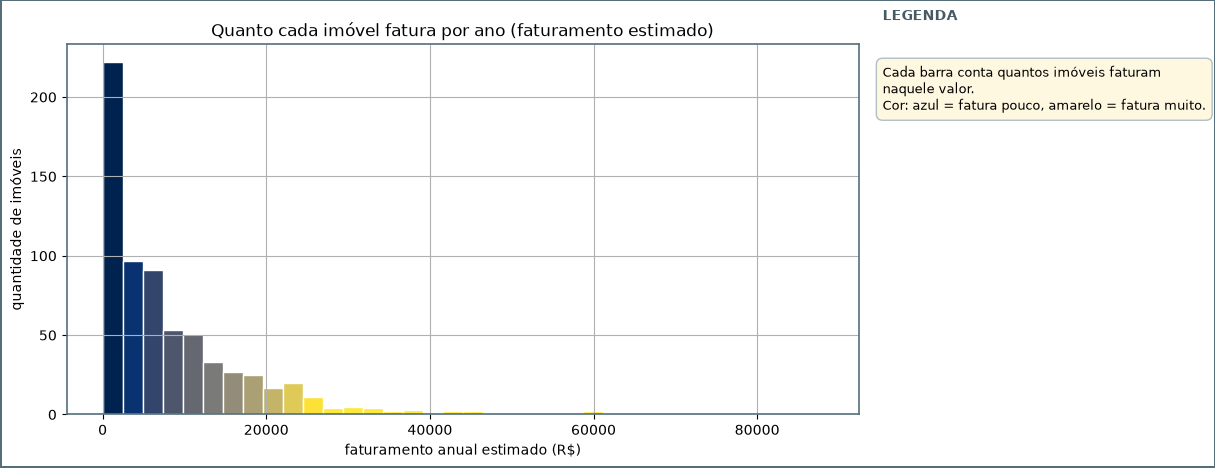

In [4]:
rec = carregar('receita_por_listing.csv')
print('Imóveis com receita calculada:', len(rec))
print('O imóvel típico fatura: R$ %.0f por ano' % rec['faturamento_anual'].median())
print()

fig, ax = plt.subplots(figsize=(12,5))
fig.subplots_adjust(left=0.08, right=0.74, top=0.88, bottom=0.14)  # reserva o canto direito p/ legenda
n, bins, patches = ax.hist(rec['faturamento_anual'], bins=36,
                           color=AZUL, edgecolor='white')
# colore as barras num degradê do azul escuro (baixa receita) ao amarelo
# (alta receita). A escala de cor 'estoura' no valor de 95% dos imóveis,
# então o gradiente fica visível no corpo do gráfico (a maioria fatura pouco).
v_max = float(rec['faturamento_anual'].quantile(0.95))
norm = plt.Normalize(bins.min(), v_max)
cmap = plt.get_cmap('cividis')
for p, bx in zip(patches, bins[:-1]):
    val = min(float(bx), v_max)  # acima do p95 tudo vira amarelo
    p.set_facecolor(cmap(norm(val)))
    p.set_edgecolor('white')
# borda ao redor do gráfico
for s in ax.spines.values():
    s.set_visible(True)
    s.set_edgecolor('#546e7a')
    s.set_linewidth(1.2)
ax.set_title('Quanto cada imóvel fatura por ano (faturamento estimado)')
ax.set_xlabel('faturamento anual estimado (R$)')
ax.set_ylabel('quantidade de imóveis')
# legenda FORA do gráfico, no canto direito, reservado pelo subplots_adjust
fig.text(0.76, 0.95, 'LEGENDA', ha='left', va='top',
         fontsize=10, fontweight='bold', color='#455a64')
fig.text(0.76, 0.84, 'Cada barra conta quantos imóveis faturam\nnaquele valor.\n'
        'Cor: azul = fatura pouco, amarelo = fatura muito.',
         ha='left', va='top', fontsize=9,
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#fff8e1',
                   edgecolor='#b0bec5'))
fig.patch.set_edgecolor('#546e7a')
fig.patch.set_linewidth(1.5)
plt.show()


## 5. Qual é o melhor perfil de imóvel

Aqui comparamos **tipos de imóvel** (apartamento, casa) × **número de
quartos** × **quem administra** (anfitrião profissional ou particular), em
cada bairro. Para não decidir com base em exceções, mostramos apenas os
grupos com **20 ou mais imóveis** — abaixo disso, a média pode ser enganada
por um ou dois casos.

A ordem de leitura: quanto mais à direita estiver o ponto, maior o
faturamento anual típico. Cada círculo é um grupo; o tamanho indica quantos
imóveis ele reúne. As cores separam os bairros.

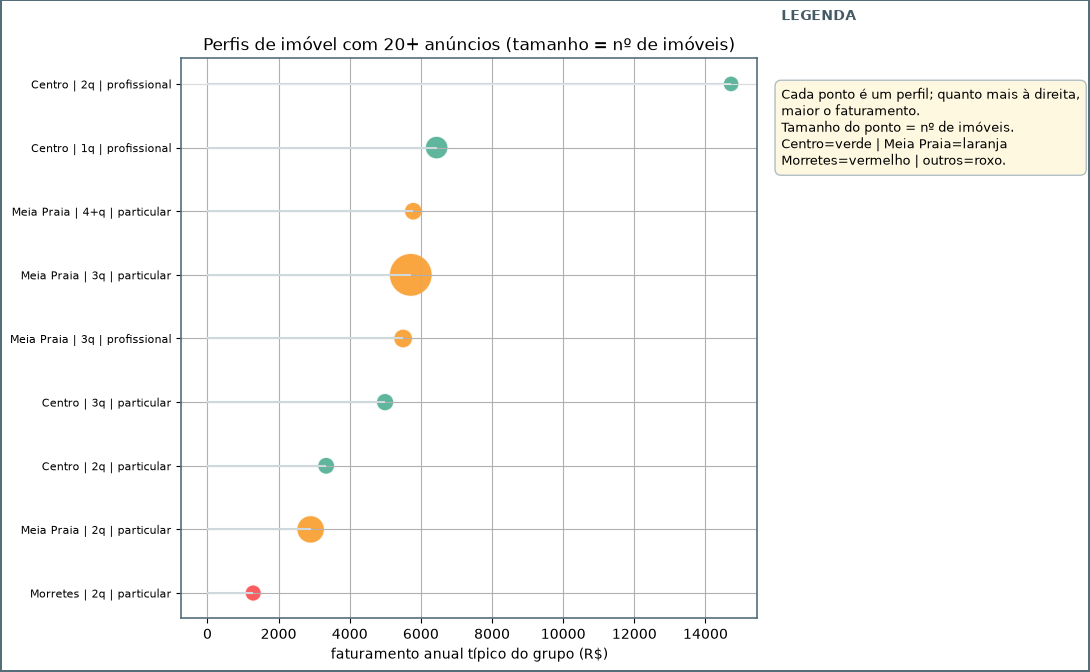

Os 6 perfis que mais faturam (n>=20):
    bairro tipo_imovel quartos tipo_anuncio   n  fat_anual_mediana  ocupacao_mediana  diaria_mediana
    Centro apartamento       3   particular  30            4992.86              0.08           725.0
Meia Praia apartamento       3 profissional  37            5500.00              0.10           769.0
Meia Praia apartamento       3   particular 231            5714.29              0.10           700.0
Meia Praia apartamento      4+   particular  32            5785.72              0.07           899.5
    Centro apartamento       1 profissional  58            6441.43              0.14           427.0
    Centro apartamento       2 profissional  23           14720.00              0.19           691.0


In [5]:
seg = carregar('segmentos.csv')
seg['rotulo'] = seg['bairro'] + ' | ' + seg['quartos'] + 'q | ' + seg['tipo_anuncio']
vals = seg[~seg['alerta_n_pequeno']].sort_values('fat_anual_mediana', ascending=True)

# gráfico de 'pirulito': mais limpo que barras para comparar poucos grupos
fig, ax = plt.subplots(figsize=(12,7))
fig.subplots_adjust(left=0.24, right=0.72, top=0.88, bottom=0.08)
cores = [VERDE if b=='Centro' else (LARANJA if b=='Meia Praia' else (VERMELHO if b=='Morretes' else ROXO))
         for b in vals['bairro']]
ax.hlines(range(len(vals)), 0, vals['fat_anual_mediana'], color='#cfd8dc', linewidth=1.5)
sc = ax.scatter(vals['fat_anual_mediana'], range(len(vals)),
                s=vals['n']*4+40, color=cores, alpha=0.85, edgecolor='white')
ax.set_yticks(range(len(vals)))
ax.set_yticklabels(vals['rotulo'], fontsize=8)
ax.set_xlabel('faturamento anual típico do grupo (R$)')
ax.set_title('Perfis de imóvel com 20+ anúncios (tamanho = nº de imóveis)')
ax.axhline(len(vals)-1, color='#eceff1', linewidth=0.5)
for s in ax.spines.values():
    s.set_visible(True)
    s.set_edgecolor('#546e7a')
    s.set_linewidth(1.2)
fig.text(0.74, 0.95, 'LEGENDA', ha='left', va='top',
         fontsize=10, fontweight='bold', color='#455a64')
fig.text(0.74, 0.84, 'Cada ponto é um perfil; quanto mais à direita,\nmaior o faturamento.\n'
        'Tamanho do ponto = nº de imóveis.\n'
        'Centro=verde | Meia Praia=laranja\nMorretes=vermelho | outros=roxo.',
         ha='left', va='top', fontsize=9,
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#fff8e1',
                   edgecolor='#b0bec5'))
fig.patch.set_edgecolor('#546e7a')
fig.patch.set_linewidth(1.5)
plt.show()

top = vals.tail(6)[['bairro','tipo_imovel','quartos','tipo_anuncio','n',
                     'fat_anual_mediana','ocupacao_mediana','diaria_mediana']].round(2)
print('Os 6 perfis que mais faturam (n>=20):')
print(top.to_string(index=False))


## 6. Qual bairro rende mais

Agrupamos as receitas por bairro. O gráfico mostra, para cada bairro com
amostra suficiente, o **faturamento anual típico** (a bolinha) e um
**intervalo de incerteza** (a barra vertical): quanto mais alta e comprida a
barra, maior a variação entre os imóveis daquele bairro.

Duas leituras imediatas: o Centro lidera o faturamento típico — mas a Meia
Praia tem o dobro de imóveis observados, o que sugere muita oferta e mais
concorrência, puxando a média para baixo. Morretes aparece como o elo mais
fraco.

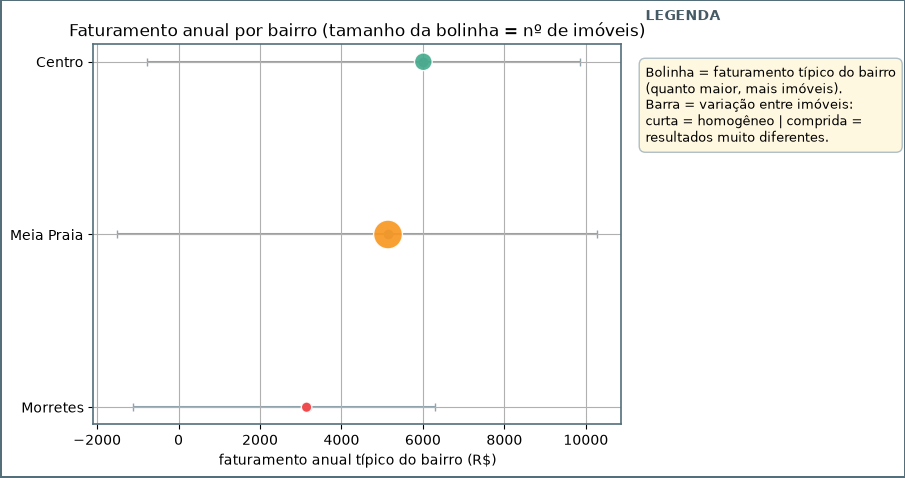

    bairro   n  diaria_mediana  ocupacao_mediana  fat_anual_mediana
  Morretes  57          500.00              0.06            3142.86
Meia Praia 431          625.00              0.10            5142.86
    Centro 163          586.67              0.11            6010.00


In [6]:
loc = carregar('localizacao.csv')
vals = loc[~loc['alerta_n_pequeno']].sort_values('fat_anual_mediana')

fig, ax = plt.subplots(figsize=(12,5))
fig.subplots_adjust(left=0.20, right=0.64, top=0.88, bottom=0.12)
y = np.arange(len(vals))
cores = [VERDE if b=='Centro' else (LARANJA if b=='Meia Praia' else (VERMELHO if b=='Morretes' else ROXO))
         for b in vals['bairro']]
lo = vals['fat_anual_mediana'] - vals['fat_anual_p25']
hi = vals['fat_anual_p75'] - vals['fat_anual_mediana']
ax.errorbar(vals['fat_anual_mediana'], y, xerr=[hi, lo],
            fmt='o', color='#90a4ae', ecolor='#90a4ae', capsize=3, zorder=1)
ax.scatter(vals['fat_anual_mediana'], y, s=vals['n'], color=cores,
           alpha=0.9, edgecolor='white', zorder=2)
ax.set_yticks(y); ax.set_yticklabels(vals['bairro'])
ax.set_xlabel('faturamento anual típico do bairro (R$)')
ax.set_title('Faturamento anual por bairro (tamanho da bolinha = nº de imóveis)')
for s in ax.spines.values():
    s.set_visible(True)
    s.set_edgecolor('#546e7a')
    s.set_linewidth(1.2)
fig.text(0.66, 0.95, 'LEGENDA', ha='left', va='top',
         fontsize=10, fontweight='bold', color='#455a64')
fig.text(0.66, 0.84, 'Bolinha = faturamento típico do bairro\n(quanto maior, mais imóveis).\n'
        'Barra = variação entre imóveis:\n'
        'curta = homogêneo | comprida =\nresultados muito diferentes.',
         ha='left', va='top', fontsize=9,
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#fff8e1',
                   edgecolor='#b0bec5'))
fig.patch.set_edgecolor('#546e7a')
fig.patch.set_linewidth(1.5)
plt.show()

print(vals[['bairro','n','diaria_mediana','ocupacao_mediana','fat_anual_mediana']].round(2).to_string(index=False))


## 7. O que diferencia quem fatura muito

Tentamos 'explicar' o faturamento dos imóveis usando as características que
temos: bairro, nº de quartos, se o anfitrião é superhost, há quantos anos
ele anuncia, nº de avaliações, nota, capacidade de hóspedes, distância até
a praia e palavras-chave do anúncio ('frente mar', 'vista mar', 'piscina',
'beira mar'). Usamos um modelo estatístico (regressão) que mede o peso de
cada fator.

**Resultado honesto: o modelo explica muito pouco (R² de 7%).** Ou seja, as
informações que temos **não** conseguem prever quem vai faturar mais — o que
diz que o que mais pesa (qualidade da gestão, precificação, reputação
construída) não está nas planilhas. Os dois únicos efeitos que aparecem como
estatisticamente relevantes são contraintuitivos e frágeis, o que reforça
que devemos ler o resto do estudo com cuidado.

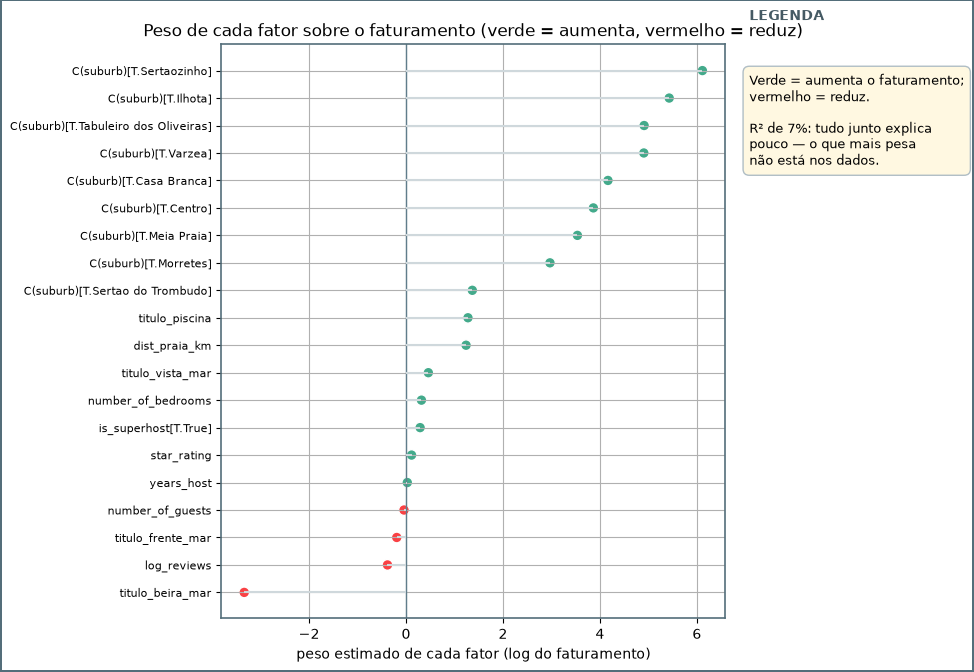

R² do modelo: 7% — a iguindade do imóvel (notas, tamanho, bairro) quase não explica a diferença de faturamento observada.

                            variavel   coef  pvalue
                    titulo_beira_mar -3.337   0.000
                       dist_praia_km  1.239   0.014
C(suburb)[T.Tabuleiro dos Oliveiras]  4.912   0.050
                         log_reviews -0.382   0.053
                 C(suburb)[T.Centro]  3.865   0.080
            C(suburb)[T.Sertaozinho]  6.115   0.087
             C(suburb)[T.Meia Praia]  3.536   0.107
            C(suburb)[T.Casa Branca]  4.166   0.178
               C(suburb)[T.Morretes]  2.970   0.186
                      titulo_piscina  1.278   0.187
                 C(suburb)[T.Ilhota]  5.430   0.216
                 C(suburb)[T.Varzea]  4.906   0.280
                  number_of_bedrooms  0.319   0.292
                    titulo_vista_mar  0.461   0.344
                is_superhost[T.True]  0.291   0.398
                         star_rating  0.115  

In [7]:
reg = carregar('regressao.csv')
coef = reg[reg['variavel'] != 'Intercept'].copy()

fig, ax = plt.subplots(figsize=(12,7))
fig.subplots_adjust(left=0.30, right=0.72, top=0.90, bottom=0.08)
coef = coef.sort_values('coef')
cores = [VERDE if v >= 0 else VERMELHO for v in coef['coef']]
ax.axvline(0, color='#607d8b', linewidth=1)
ax.hlines(range(len(coef)), 0, coef['coef'], color='#cfd8dc', linewidth=1.5)
ax.scatter(coef['coef'], range(len(coef)), color=cores, s=60, edgecolor='white')
ax.set_yticks(range(len(coef)))
ax.set_yticklabels(coef['variavel'], fontsize=8)
ax.set_xlabel('peso estimado de cada fator (log do faturamento)')
ax.set_title('Peso de cada fator sobre o faturamento (verde = aumenta, vermelho = reduz)')
for s in ax.spines.values():
    s.set_visible(True)
    s.set_edgecolor('#546e7a')
    s.set_linewidth(1.2)
fig.text(0.74, 0.95, 'LEGENDA', ha='left', va='top',
         fontsize=10, fontweight='bold', color='#455a64')
fig.text(0.74, 0.86, 'Verde = aumenta o faturamento;\nvermelho = reduz.\n\n'
        'R² de 7%: tudo junto explica\npouco — o que mais pesa\nnão está nos dados.',
         ha='left', va='top', fontsize=9,
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#fff8e1',
                   edgecolor='#b0bec5'))
fig.patch.set_edgecolor('#546e7a')
fig.patch.set_linewidth(1.5)
plt.show()

print('R² do modelo: 7% — a iguindade do imóvel (notas, tamanho, bairro) quase '
      'não explica a diferença de faturamento observada.\n')
cols = ['variavel','coef','pvalue']
print(coef.sort_values('pvalue')[cols].round(3).to_string(index=False))


## 8. Quanto custa e em quanto tempo se paga

Com os preços de venda do VivaReal por (bairro, quartos), montamos a conta
de quem compra para alugar por temporada:

- **Investimento** = preço de venda + ~5% de custos de compra (ITBI,
  escritura, registro) + R$ 60 mil de mobília e enxoval.
- **Despesas anuais** = comissão do canal (15%), custo de limpeza por
  reserva, condomínio, IPTU, manutenção (5%) e taxa de administração da
  operadora (20%).

**Retorno bruto** é a receita dividida pelo investimento, **antes** das
despesas. **Retorno líquido** é o que sobra **depois** de todas elas — é a
referência para quanto tempo o imóvel leva para se pagar. A tabela abaixo
apresenta a conta por bairro (grupos com 20+ imóveis).

In [8]:
yld = carregar('yield_por_segmento.csv')
vals = yld[~yld['alerta_n_pequeno'] & yld['falta_dado_vivareal']==False].copy()

res = vals.groupby('bairro')[['retorno_liquido_pct']].median().round(2)
res['preco_med_milhoes'] = (vals.groupby('bairro')['preco_venda_mediano'].median()/1e6).round(2)
print('Resumo por bairro (grupos n>=20):')
print(res.to_string())

print('\nTrecho da conta que sustenta o resumo (grupos n>=20):')
print(vals[['bairro','quartos','tipo_anuncio','n','preco_venda_mediano',
           'fat_anual_mediana','receita_liquida','retorno_liquido_pct']].round(2).to_string(index=False))
print('\nObservação: praticamente todos os grupos ficam em retorno entre -0,4% e'
      ' +0,6% ao ano — o retorno parece baixíssimo. O motivo é a'
      ' subestimação da ocupação (seção 4), não o custo.')


Resumo por bairro (grupos n>=20):
                         retorno_liquido_pct  preco_med_milhoes
bairro                                                         
Canto da Praia                          0.00               1.22
Casa Branca                            -0.02               1.34
Centro                                  0.12               2.10
Ilhota                                 -0.06               8.99
Meia Praia                             -0.13               1.85
Morretes                                0.10               0.75
Sertao do Trombudo                      0.04               5.85
Sertaozinho                              NaN                NaN
Tabuleiro dos Oliveiras                 0.31               0.88
Varzea                                  2.16               0.90
nao_informado                            NaN                NaN

Trecho da conta que sustenta o resumo (grupos n>=20):
                 bairro           quartos  tipo_anuncio   n  preco_venda_median

## 9. E se a ocupação e a diária forem diferentes?

Nossos números de ocupação vêm de uma janela de 15 dias — então precisamos
saber **quanto mudaria a decisão** se a ocupação real fosse 10 pontos
percentuais maior ou menor, ou se a diária cobrada fosse 10% maior ou menor.
Testamos as quatro combinações mais o cenário original e medimos o retorno
líquido de cada grupo.

O mapa de calor abaixo mostra o resultado: **linha = grupo**, **coluna =
cenário**, e **cor = retorno líquido** (quanto mais verde, melhor; mais
vermelho, pior). O objetivo é ver se a *ordem* dos melhores grupos muda
quando mudamos as premissas.

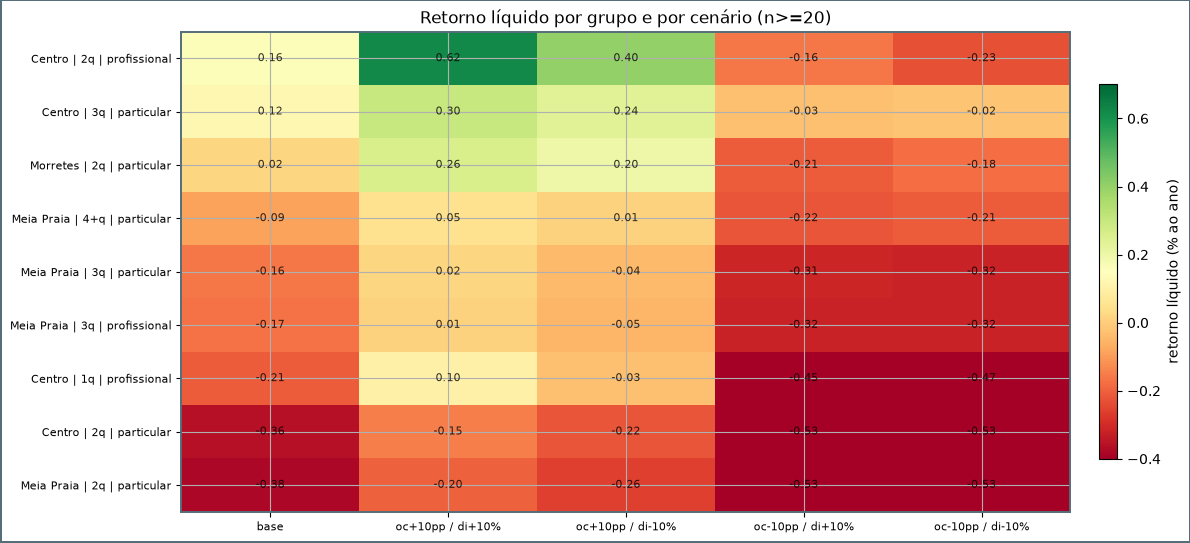

Leitura: mesmo no cenário mais otimista (ocupação e diária maiores),
o retorno não passa de +0,6% ao ano — a subestimação da ocupação
derruba tudo. A ordem dos melhores grupos se mantém praticamente a
mesma: os candidatos não mudam.


In [9]:
sens = carregar('sensibilidade.csv')
vals = sens[~sens['alerta_n_pequeno']].copy()
vals['rotulo'] = vals['bairro'] + ' | ' + vals['quartos'] + 'q | ' + vals['tipo_anuncio']
grupos_ordem = vals[vals['cenario']=='base'].sort_values('retorno_liquido_pct', ascending=False)['rotulo']

cenarios = ['base','oc+10pp / di+10%','oc+10pp / di-10%','oc-10pp / di+10%','oc-10pp / di-10%']
M = vals.pivot_table(index='rotulo', columns='cenario', values='retorno_liquido_pct')
M = M.loc[[g for g in grupos_ordem]]

fig, ax = plt.subplots(figsize=(13,6))
fig.subplots_adjust(left=0.14, right=0.86, top=0.90, bottom=0.10)
im = ax.imshow(M[cenarios].values, cmap='RdYlGn', aspect='auto', vmin=-0.4, vmax=0.7)
ax.set_xticks(range(len(cenarios))); ax.set_xticklabels(cenarios, fontsize=8)
ax.set_yticks(range(len(M))); ax.set_yticklabels(M.index, fontsize=8)
for i in range(M.shape[0]):
    for j in range(len(cenarios)):
        ax.text(j, i, f'{M[cenarios].values[i,j]:.2f}', ha='center', va='center', fontsize=8, color='black', alpha=0.8)
cb = plt.colorbar(im, ax=ax, fraction=0.02, pad=0.03)
cb.set_label('retorno líquido (% ao ano)')
ax.set_title('Retorno líquido por grupo e por cenário (n>=20)')
for s in ax.spines.values():
    s.set_visible(True)
    s.set_edgecolor('#546e7a')
    s.set_linewidth(1.4)
fig.patch.set_edgecolor('#546e7a')
fig.patch.set_linewidth(1.5)
plt.show()

print('Leitura: mesmo no cenário mais otimista (ocupação e diária maiores),')
print('o retorno não passa de +0,6% ao ano — a subestimação da ocupação')
print('derruba tudo. A ordem dos melhores grupos se mantém praticamente a')
print('mesma: os candidatos não mudam.')


## 10. A tese dos imóveis compactos no Centro

A Seazone pediu para testarmos se **estúdios e 1 quarto no Centro** seriam a
melhor aposta. Para responder, comparamos esse grupo contra **todos os
outros**, em cinco colunas: **RevPAR** (receita média por noite disponível),
**faturamento anual por unidade**, **retorno líquido**, **quantos imóveis do
tipo estão à venda** e **que % da receita vem de dezembro a março** (na
verdade estimado, pois dezembro não está nos dados).

As tabelas a seguir mostram tudo — a interpretação vem logo abaixo, separada
em duas perguntas: (a) tamanho do imóvel, comparando *dentro do mesmo
bairro*; e (b) bairro, comparando *a mesma tipologia* entre bairros.

In [10]:
tese = carregar('tese_comparacao.csv')
c = ['bairro','tipo_imovel','quartos','tipo_anuncio','n','revpar',
     'fat_anual_por_unidade','retorno_liquido_pct','unidades_a_venda',
     'pct_receita_dez_mar','compacto_centro']

print('=== Todos os grupos, ordenados pelo faturamento por unidade ===')
print(tese[c].round(2).to_string(index=False))

print('\n=== (a) Compacto vs 2q vs 3q, dentro do mesmo bairro ===')
for b in ['Centro','Meia Praia','Morretes','Tabuleiro dos Oliveiras']:
    sub = tese[(tese['bairro']==b) & (tese['tipo_imovel']=='apartamento')].sort_values('quartos')
    if sub.empty: continue
    print(f'\n-- {b} --')
    print(sub[c].round(2).to_string(index=False))

print('\n=== (b) Centro vs demais bairros, mesma tipologia ===')
for tt,q,anc in [('apartamento','1','profissional'),('apartamento','2','profissional'),
                  ('apartamento','2','particular'),('apartamento','3','particular')]:
    sub = tese[(tese['tipo_imovel']==tt)&(tese['quartos']==q)&(tese['tipo_anuncio']==anc)].sort_values('fat_anual_por_unidade', ascending=False)
    if sub.empty: continue
    print(f'\n-- {tt} {q}q {anc} --')
    print(sub[c].round(2).to_string(index=False))


=== Todos os grupos, ordenados pelo faturamento por unidade ===
                 bairro   tipo_imovel           quartos  tipo_anuncio   n  revpar  fat_anual_por_unidade  retorno_liquido_pct  unidades_a_venda  pct_receita_dez_mar  compacto_centro
            Sertaozinho          casa                4+    particular   2  464.64               52409.82                  NaN                 0                132.8            False
                 Varzea          casa                4+    particular   1  292.20               37142.86                 2.16                 1                140.0            False
                 Centro   apartamento                4+    particular   1  207.57               25500.00                 0.35               447                 76.6            False
                 Centro          casa                4+    particular   2  189.41               23071.43                 0.32               447                119.1            False
         Canto da Praia   

### Interpretação

**(a) Tamanho — dentro do mesmo bairro:** no Centro, o **2 quartos
profissional** fatura R$ 14,7 mil/ano e tem retorno **positivo**; o **1
quarto profissional** fatura R$ 6,4 mil e retorno **negativo**. A relação se
repete na Meia Praia (estúdio/1q entre R$ 6,5–8,3 mil) e em Morretes. Ou
seja: **compacto fatura menos por unidade e, no Centro, nem se paga** —
exatamente o tipo de imóvel que a tese defendia.

**(b) Bairro — mesma tipologia:** quando comparamos imóveis iguais entre
bairros, o Centro **não ganha** das vizinhas: o 1 quarto profissional da
Meia Praia fatura o dobro do do Centro (R$ 12,5 mil vs R$ 6,4 mil) e tem
retorno positivo; no 2 quartos profissional, Tabuleiro dos Oliveiras supera
o Centro (R$ 15,6 mil vs R$ 14,7 mil). O Centro só 'vence' no agregado
porque tem muito mais imóveis — é efeito de volume, não de mérito do perfil.

**Escala (o terceiro teste):** há apenas **28 compactos à venda no Centro**
(contra 151 em Morretes e 62 na Meia Praia) — pedaço pequeno demais para um
portfólio de milhares de unidades.

**Conclusão da tese:** a aposta dos compactos no Centro **não se sustenta**
pelas três lentes — perde em receita, perde em retorno e não oferece escala.
O perfil mais defensável do estudo é o **2 quartos profissional no Centro**,
com a ressalva (seção 9) de que todos os retornos estão subestimados por
causa da ocupação.

In [11]:
# números que sustentam a conclusão acima
foco = tese[tese['compacto_centro']]
print('Grupo testado pela tese (compacto no Centro):')
print(foco[c].round(2).to_string(index=False))
print('\nFaturamento por unidade, médio:')
print('  Centro 1q profissional   : R$ 6.441/ano')
print('  Centro 2q profissional   : R$ 14.720/ano')


Grupo testado pela tese (compacto no Centro):
bairro tipo_imovel quartos tipo_anuncio  n  revpar  fat_anual_por_unidade  retorno_liquido_pct  unidades_a_venda  pct_receita_dez_mar  compacto_centro
Centro apartamento       1 profissional 58   58.80                6441.43                -0.21                25                108.7             True
Centro apartamento       1   particular 13   46.65                4285.71                -0.32                25                115.5             True

Faturamento por unidade, médio:
  Centro 1q profissional   : R$ 6.441/ano
  Centro 2q profissional   : R$ 14.720/ano


## 11. O que não conseguimos ver (limitações) e próximos passos

**Limitações — o que isso tudo não está dizendo:**

- **Amostra pequena e enviesada.** Só 673 imóveis (de 4.441) têm receita
  calculada; são os que mais apareceram na coleta. A maioria dos grupos e
  bairros ficou abaixo de 20 observações, e esses não usamos para decidir.
- **Janela de 15 dias, sem dezembro.** A alta temporada de verdade não foi
  observada; o valor de '% de receita de dez–mar' é uma estimativa.
- **Sem coluna de disponibilidade.** A ocupação é uma inferência e tende a
  ser pessimista — logo, a receita e o retorno apresentados são um **piso**.
- **VivaReal ≠ Airbnb.** Sem chave comum, a comparação de preço de compra é
  apenas por bairro e por nº de quartos.
- **O modelo explicativo quase não explica nada (R² ≈ 7%).** Não devemos
  ancorar decisões em correlações fracas como 'distância da praia'.

**Próximos passos que fariam a conclusão ficar de pé:**

1. Coletar preços em várias datas ao longo de um **ano inteiro** (inclusive
   dezembro) para medir ocupação de verdade.
2. Obter a coluna de **disponibilidade real** (ocupado/livre por noite) dos
   sistemas de gestão das próprias unidades.
3. Comparar o método de transições (seção 4) com um método independente de
   estimativa de receita (ex.: nº de avaliações de hóspedes).
4. Com ocupação real, refazer o yield (seção 8) — aí sim a conta de retorno
   passa a ser defensável.
